**STEP:1**

In [40]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
import pandas as pd
file_path='/content/drive/MyDrive/ANLP/Datasets/tweet_emotions.csv'

In [6]:
df=pd.read_csv(file_path)
df.head()

,Id,Tweet,Label
0,145353048817012000,Thinks that @melbahughes had a great 50th birt...,surprise
1,144279638024257000,"Como una expresiÃ³n tan simple, una sola oraci...",sadness
2,140499585285111000,the moment when you get another follower and y...,joy
3,145207578270507000,Be the greatest dancer of your life! practice ...,joy
4,139502146390470000,eww.. my moms starting to make her annual rum ...,disgust


In [7]:
df.columns

Index(['Id', 'Tweet', 'Label'], dtype='object')

In [8]:
#no of instances per class labels
df['Label'].value_counts()


,count
Label,
joy,8240
surprise,3849
sadness,3830
fear,2816
anger,1555
disgust,761


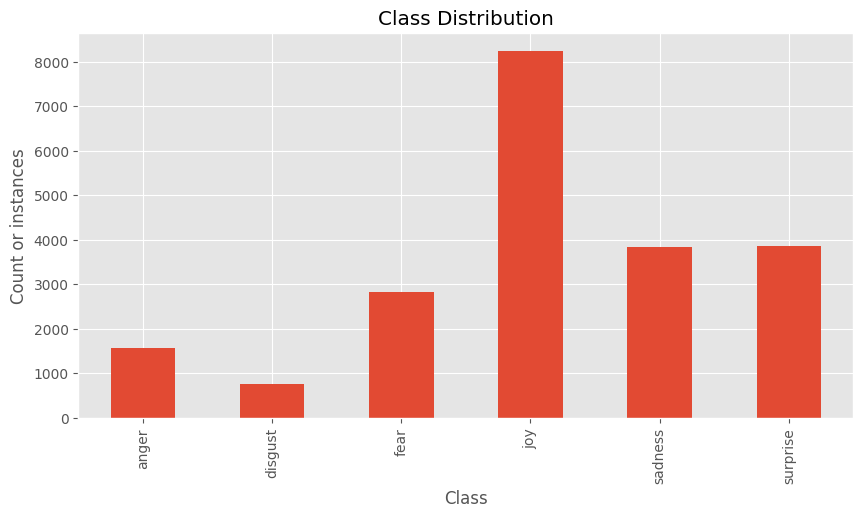

In [13]:
import matplotlib.pyplot as plt
plt.style.use('ggplot')
df['Label'].value_counts().sort_index().plot(kind='bar', title='Class Distribution', figsize=(10,5))
plt.xlabel('Class')
plt.ylabel('Count or instances') # Added y-axis label for clarity
plt.show()

**Data Preprocessing**





In [14]:
if 'Id' in df.columns:
    df.drop('Id', axis=1, inplace=True)
    print("'Id' column dropped.")
else:
    print("'Id' column not found, already dropped or never existed.")
df.head()

'Id' column dropped.


,Tweet,Label
0,Thinks that @melbahughes had a great 50th birt...,surprise
1,"Como una expresiÃ³n tan simple, una sola oraci...",sadness
2,the moment when you get another follower and y...,joy
3,Be the greatest dancer of your life! practice ...,joy
4,eww.. my moms starting to make her annual rum ...,disgust


In [17]:
import re
import string
# The nltk import and stopwords download/usage are removed as they are not needed for this simpler cleaning.

def clean_text(text):
    # 1. Convert to lowercase
    text = text.lower()
    # 2. Remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))
    # 3. Remove extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['cleaned_tweet'] = df['Tweet'].apply(clean_text)
print("Text cleaning function defined and applied to 'Tweet' column to create 'cleaned_tweet' with simple cleaning.")
print("Displaying the first 5 rows with original and cleaned tweet:")
print(df[['Tweet', 'cleaned_tweet']].head().to_markdown(index=False))

Text cleaning function defined and applied to 'Tweet' column to create 'cleaned_tweet' with simple cleaning.
Displaying the first 5 rows with original and cleaned tweet:
| Tweet                                                                                                               | cleaned_tweet                                                                                            |
|:--------------------------------------------------------------------------------------------------------------------|:---------------------------------------------------------------------------------------------------------|
| Thinks that @melbahughes had a great 50th birthday party :)                                                         | thinks that melbahughes had a great 50th birthday party                                                  |
| Como una expresiÃ³n tan simple, una sola oraciÃ³n, puede llegara daÃ±arte tanto.                                    | como una expresiã³n tan simpl

In [18]:
from tensorflow.keras.preprocessing.text import Tokenizer

# Initialize Tokenizer with a suitable vocabulary size and OOV token
# Using max_words = 5000 from the kernel state as an example
max_words = 5000  # Define max_words for consistency
tokenizer = Tokenizer(num_words=max_words, oov_token='<unk>')

# Fit the tokenizer on the 'cleaned_tweet' column to build the vocabulary
tokenizer.fit_on_texts(df['cleaned_tweet'])

# Convert the 'cleaned_tweet' column into sequences of integers
sequences = tokenizer.texts_to_sequences(df['cleaned_tweet'])

# Print the number of unique tokens found by the tokenizer (actual vocabulary size)
print(f"Total unique tokens found (including OOV token): {len(tokenizer.word_index)}")

# Print the first few generated sequences to inspect the output
print("\nFirst 5 generated sequences:")
for i, seq in enumerate(sequences[:5]):
    print(f"Sequence {i+1}: {seq}")

Total unique tokens found (including OOV token): 35340

First 5 generated sequences:
Sequence 1: [1603, 15, 1, 89, 5, 127, 1, 191, 248]
Sequence 2: [2469, 1220, 1, 2185, 1221, 1220, 4751, 1, 1, 1, 1, 2470]
Sequence 3: [2, 160, 27, 12, 40, 181, 1763, 7, 12, 932]
Sequence 4: [19, 2, 780, 1, 8, 26, 75, 444, 1057, 1379, 4077, 302, 1538, 4077]
Sequence 5: [3220, 6, 882, 672, 4, 86, 118, 3221, 1, 948, 11, 2, 338, 1, 139, 1186, 1186, 1186, 2, 1]


In [19]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Define a maximum sequence length for padding
# Using max_sequence_length = 100 from the kernel state
max_sequence_length = 100

# Pad sequences to ensure uniform length
X = pad_sequences(sequences, maxlen=max_sequence_length, padding='post')

print(f"Padded sequences (X) shape: {X.shape}")
print("First 5 padded sequences (first 10 elements):")
for i, seq in enumerate(X[:5]):
    print(f"Sequence {i+1}: {seq[:10]}")

Padded sequences (X) shape: (21051, 100)
First 5 padded sequences (first 10 elements):
Sequence 1: [1603   15    1   89    5  127    1  191  248    0]
Sequence 2: [2469 1220    1 2185 1221 1220 4751    1    1    1]
Sequence 3: [   2  160   27   12   40  181 1763    7   12  932]
Sequence 4: [  19    2  780    1    8   26   75  444 1057 1379]
Sequence 5: [3220    6  882  672    4   86  118 3221    1  948]


In [20]:
from sklearn.preprocessing import LabelEncoder

# Initialize LabelEncoder
label_encoder = LabelEncoder()

# Fit and transform the 'Label' column to create numerical labels
y_encoded = label_encoder.fit_transform(df['Label'])

# Print the mapping of original labels to encoded integers
print("Label mapping (original -> encoded):")
for i, label in enumerate(label_encoder.classes_):
    print(f"  {label} -> {i}")

# Print the shape of the encoded labels and first few values
print(f"\nShape of encoded labels (y_encoded): {y_encoded.shape}")
print(f"First 5 encoded labels: {y_encoded[:5]}")

Label mapping (original -> encoded):
  anger -> 0
  disgust -> 1
  fear -> 2
  joy -> 3
  sadness -> 4
  surprise -> 5

Shape of encoded labels (y_encoded): (21051,)
First 5 encoded labels: [5 4 3 3 1]


In [34]:
from tensorflow.keras.utils import to_categorical

# Get the number of unique classes
num_classes = len(label_encoder.classes_)

# Convert integer labels to one-hot encoded format
y = to_categorical(y_encoded, num_classes=num_classes)

print(f"Original encoded labels shape: {y_encoded.shape}")
print(f"One-hot encoded labels (y) shape: {y.shape}")
print("First 5 one-hot encoded labels:")
print(y[:5])

Original encoded labels shape: (21051,)
One-hot encoded labels (y) shape: (21051, 6)
First 5 one-hot encoded labels:
[[0. 0. 0. 0. 0. 1.]
 [0. 0. 0. 0. 1. 0.]
 [0. 0. 0. 1. 0. 0.]
 [0. 0. 0. 1. 0. 0.]
 [0. 1. 0. 0. 0. 0.]]


In [35]:
from sklearn.model_selection import train_test_split

# Split the data into training and testing sets (e.g., 80% train, 20% test)
# Use stratify to maintain class distribution in both sets, as mentioned in the problem summary.
# Set a random_state for reproducibility.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

Shape of X_train: (16840, 100)
Shape of X_test: (4211, 100)
Shape of y_train: (16840, 6)
Shape of y_test: (4211, 6)


In [37]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Flatten, Dense

# Instantiate a Sequential model
model = Sequential()

# Add an Embedding layer
# input_dim: max_words (vocabulary size) - using the kernel variable
# output_dim: 100 (dimension of the dense embedding)
# input_length: max_sequence_length (length of input sequences) - using the kernel variable
model.add(Embedding(input_dim=max_words, output_dim=100, input_length=max_sequence_length))

# Add a Flatten layer to convert the 2D embedding output to 1D
model.add(Flatten())

# Add the first Dense hidden layer
model.add(Dense(64, activation='relu'))

# Add the second Dense hidden layer
model.add(Dense(32, activation='relu'))

# Add the final Dense output layer
# num_classes: number of unique labels - using the kernel variable
# activation='softmax' for multi-class classification
model.add(Dense(num_classes, activation='softmax'))

# Explicitly build the model to ensure all layers are created before summary
model.build(input_shape=(None, max_sequence_length))

# Compile the model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

print("Keras Sequential model defined and compiled successfully.")
model.summary()

Keras Sequential model defined and compiled successfully.


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_6 (Embedding)         │ (None, 100, 100)       │       500,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_6 (Flatten)             │ (None, 10000)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 64)             │       640,064 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 6)              │           198 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,142,342 (4.36 MB)

 Trainable params: 1,142,342 (4.36 MB)

 Non-trainable params: 0 (0.00 B)

In [47]:
final_train_accuracy = history.history['accuracy'][-1]

print(f"Final Training Accuracy: {final_train_accuracy:.4f}")
print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")

Final Training Accuracy: 0.9999
Test Loss: 3.4030
Test Accuracy: 0.5234


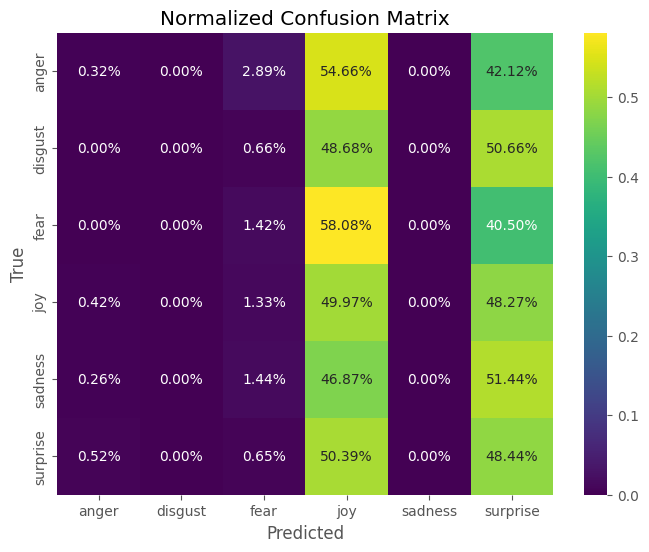

In [50]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Compute and normalize the confusion matrix
cm = confusion_matrix(y_true_classes, y_pred_classes)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

# Plot the normalized confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm_normalized, annot=True, fmt='.2%', cmap='viridis',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Normalized Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

In [42]:
import numpy as np
from sklearn.metrics import classification_report

# Make predictions on the test set
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true_classes = np.argmax(y_test, axis=1)

# Get the class names from the LabelEncoder
class_names = list(label_encoder.classes_)

# Generate and print the classification report
print("Classification Report:")
print(classification_report(y_true_classes, y_pred_classes, target_names=class_names))

132/132 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step
Classification Report:
              precision    recall  f1-score   support

       anger       0.07      0.00      0.01       311
     disgust       0.00      0.00      0.00       152
        fear       0.14      0.01      0.03       563
         joy       0.38      0.50      0.43      1649
     sadness       0.00      0.00      0.00       766
    surprise       0.19      0.48      0.27       770

    accuracy                           0.29      4211
   macro avg       0.13      0.17      0.12      4211
weighted avg       0.21      0.29      0.22      4211



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
